This file is where the real test comes in: will adding features tracking a games similarity to hti games result in better outcomes for the model?

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer

df = pd.read_pickle('../data/cleaned_games.pkl')

df = df.sort_values('release_date').reset_index(drop=True)

I am using a pre-built neural network model to encode the test descriptions of the games in the data set to then create a numerical score to represent similarities the games decription has to games that have already been created that fall into the hit category. This, along with metadata is the crux of my model, and I would like to see if it actually results in a superior model.

Note: the following code block is to remove common phrases that indicate re-releases of already successfull games that are unwanted noise for the purposes of this model.

In [2]:
def clean_description(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()

    text = re.sub(r"collector'?s edition", "", text)
    text = re.sub(r"complete edition", "", text)
    text = re.sub(r"game of the year edition", "", text)
    text = re.sub(r"definitive edition", "", text)

    text = re.sub(r"[^\w\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    
    return text


In [3]:

df['clean_description'] = df['description'].apply(clean_description)

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    df['clean_description'].tolist(),
    batch_size=32,
    show_progress_bar=True
)

df['embedding'] = list(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3564 [00:00<?, ?it/s]

Now I will take the embedded vectors to return a game's "similarity score" calculated with a cosine similarity function on the vectors compared with the vectors of all games released before that fall into "hit" and store the maximum similarity in a new column. I will also store the time since the hit game as a second metric to match with the similarity score.

In [5]:
similarity_scores = []
time_since_similar = []

past_embeddings = []
past_hits = []
past_dates = []

for i, row in df.iterrows():
    current_vec = row['embedding']
    current_date = row['release_date']
    
    # indices of past successful games
    hit_indices = [j for j in range(len(past_hits)) if past_hits[j] == 1]
    
    if len(hit_indices) == 0:
        sim = 0
        time_gap = 0
    else:
        hit_vectors = [past_embeddings[j] for j in hit_indices]
        
        sims = cosine_similarity([current_vec], hit_vectors)[0]

        # --- Top-K similarity ---
        k = min(5, len(sims))
        top_k_idx = np.argsort(sims)[-k:]

        top_sims = sims[top_k_idx]

        # map back to original indices
        top_hit_indices = [hit_indices[idx] for idx in top_k_idx]

        top_time_gaps = np.array([
            (current_date - past_dates[j]).days
            for j in top_hit_indices
        ])

        weights = 1 / (1 + top_time_gaps)

        sim = np.sum(top_sims * weights) / np.sum(weights)

        # --- Best match for time feature ---
        best_local_idx = np.argmax(sims)
        best_global_idx = hit_indices[best_local_idx]

        past_date = past_dates[best_global_idx]
        time_gap = (current_date - past_date).days
    
    similarity_scores.append(sim)
    time_since_similar.append(time_gap)
    
    # update history
    past_embeddings.append(current_vec)
    past_hits.append(row['hit'])
    past_dates.append(current_date)

# final features
df['sim_to_past_hits'] = similarity_scores
df['log_days_since_similar_hit'] = np.log1p(time_since_similar)

In [6]:
df['sim_dev_interaction'] = df['sim_to_past_hits'] * df['dev_success']
df['sim_time_interaction'] = df['sim_to_past_hits'] * (1 / (1 + df['log_days_since_similar_hit']))

In [7]:
with open('../data/genre_columns.pkl', 'rb') as f:
    genre_features = pickle.load(f)

features_clean_3 = [
    'price',
    'year',
    'dev_success',
    'dev_had_success',
    'log_dev_experience',
    'num_devs',
    'sim_to_past_hits',
    'log_days_since_similar_hit',
    'sim_dev_interaction',
    'sim_time_interaction'
] + list(genre_features)


X = df[features_clean_3]
y = df['hit']

split_index = int(len(df) * 0.7)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]



In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [9]:
threshold = 0.5

y_probs = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_probs > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Miss', 'Actual: Hit'], columns=['Predicted: Miss', 'Predicted: Hit'])
display(cm_df)

Accuracy: 0.9417146531817252
F1 Score: 0.21434200157604413
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     33069
           1       0.19      0.24      0.21      1142

    accuracy                           0.94     34211
   macro avg       0.58      0.60      0.59     34211
weighted avg       0.95      0.94      0.94     34211



,Predicted: Miss,Predicted: Hit
Actual: Miss,31945,1124
Actual: Hit,870,272


In [10]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values(by='coefficient', ascending=False)

print(coef_df.head(15))

                  feature  coefficient
2             dev_success     0.457768
6        sim_to_past_hits     0.195945
22           Free To Play     0.186766
3         dev_had_success     0.170302
30                    RPG     0.158526
34             Simulation     0.107687
37               Strategy     0.102023
13              Adventure     0.099876
8     sim_dev_interaction     0.089739
12                 Action     0.069829
26  Massively Multiplayer     0.056347
0                   price     0.047786
42         Web Publishing     0.042125
5                num_devs     0.027735
27                  Movie     0.024585


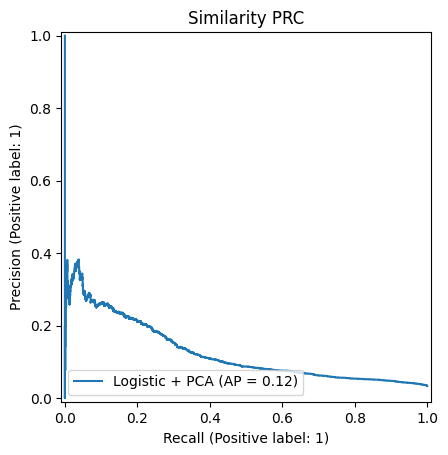

In [30]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test,
    name="Logistic + PCA"
)

plt.title("Similarity PRC")
plt.show()

In [12]:

def evaluate_model(model, X_train, X_test, y_train, y_test, threshold=0.5):
    model.fit(X_train, y_train)
    
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > threshold).astype(int)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=['Actual: Miss', 'Actual: Hit'], columns=['Predicted: Miss', 'Predicted: Hit'])
    display(cm_df)
    
    return f1_score(y_test, y_pred)

In [13]:
log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

f1_log = evaluate_model(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    threshold=0.5
)

Accuracy: 0.9417146531817252
F1 Score: 0.21434200157604413
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     33069
           1       0.19      0.24      0.21      1142

    accuracy                           0.94     34211
   macro avg       0.58      0.60      0.59     34211
weighted avg       0.95      0.94      0.94     34211



,Predicted: Miss,Predicted: Hit
Actual: Miss,31945,1124
Actual: Hit,870,272


In [14]:
lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=3000,
    class_weight='balanced'
)

f1_lasso = evaluate_model(
    lasso_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    threshold=0.5
)

/Users/jcook/Video-Game-Sales-Analysis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/jcook/Video-Game-Sales-Analysis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Accuracy: 0.9417731139107305
F1 Score: 0.21451104100946372
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     33069
           1       0.20      0.24      0.21      1142

    accuracy                           0.94     34211
   macro avg       0.58      0.60      0.59     34211
weighted avg       0.95      0.94      0.94     34211



,Predicted: Miss,Predicted: Hit
Actual: Miss,31947,1122
Actual: Hit,870,272


In [15]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso_model.coef_[0]
})

print(coef_df[coef_df['coefficient'] != 0].sort_values(by='coefficient', ascending=False))

                       feature  coefficient
2                  dev_success     0.457020
6             sim_to_past_hits     0.195875
22                Free To Play     0.186660
3              dev_had_success     0.169992
30                         RPG     0.158476
34                  Simulation     0.107513
37                    Strategy     0.101957
13                   Adventure     0.099837
8          sim_dev_interaction     0.090605
12                      Action     0.069784
26       Massively Multiplayer     0.056287
0                        price     0.047633
42              Web Publishing     0.041881
5                     num_devs     0.027680
39                   Utilities     0.023550
11                  Accounting     0.017273
14        Animation & Modeling     0.012952
27                       Movie     0.012422
24                        Gore     0.009462
7   log_days_since_similar_hit     0.000467
35           Software Training    -0.000161
31                      Racing  

In [16]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced'
)

f1_svm = evaluate_model(
    svm_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    threshold=0.5
)

Accuracy: 0.9634328140071907
F1 Score: 0.18395303326810175
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     33069
           1       0.36      0.12      0.18      1142

    accuracy                           0.96     34211
   macro avg       0.67      0.56      0.58     34211
weighted avg       0.95      0.96      0.95     34211



,Predicted: Miss,Predicted: Hit
Actual: Miss,32819,250
Actual: Hit,1001,141


In [17]:
print("Logistic F1:", f1_log)
print("Lasso F1:", f1_lasso)
print("SVM F1:", f1_svm)

Logistic F1: 0.21434200157604413
Lasso F1: 0.21451104100946372
SVM F1: 0.18395303326810175


The findings show that the addition of imitation features that I came up with does not result in any significant change to the success of the predicition model. However, there may still be a way to improve the model but utilizing Principal Component Analysis on the sentence embedding to see if there is information in the descriptions that can contribute to a more successful game that is not based solely around similarity to other successful games. This should also hopefully have a better outcome with the svm model, as I think it was poor to utilize it on the set of features that I did.

In [18]:
embedding_matrix = np.stack(df['embedding'].values)

split_index = int(len(df) * 0.7)

emb_train = embedding_matrix[:split_index]
emb_test = embedding_matrix[split_index:]

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=46, random_state=42)

emb_train_reduced = pca.fit_transform(emb_train)
emb_test_reduced = pca.transform(emb_test)

In [20]:
X_train_final = np.hstack([X_train_scaled, emb_train_reduced])
X_test_final = np.hstack([X_test_scaled, emb_test_reduced])

In [21]:
model_pca = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

model_pca.fit(X_train_final, y_train)

y_probs = model_pca.predict_proba(X_test_final)[:, 1]
y_pred = (y_probs > 0.6).astype(int)

print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Miss', 'Actual: Hit'], columns=['Predicted: Miss', 'Predicted: Hit'])
display(cm_df)

F1: 0.22854561878952123
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     33069
           1       0.24      0.22      0.23      1142

    accuracy                           0.95     34211
   macro avg       0.60      0.60      0.60     34211
weighted avg       0.95      0.95      0.95     34211



,Predicted: Miss,Predicted: Hit
Actual: Miss,32250,819
Actual: Hit,889,253


This is a non-insignifcant improvement despite how small it is. This is the best model result so far, with the PCA features from description embedding improving the F1 score from the base model by about 5%. Due to the small class size of the sought out result, I wanted to display the model's Precision-Recall curve. For the purposes of this model, a higher precision is more ideal, but only while still producing a large number of positive classifications.

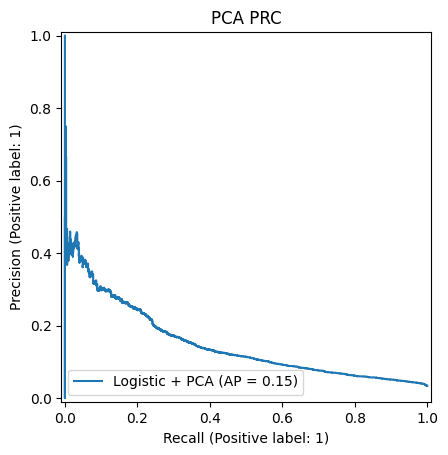

In [28]:
PrecisionRecallDisplay.from_estimator(
    model_pca,
    X_test_final,
    y_test,
    name="Logistic + PCA"
)

plt.title("PCA PRC")
plt.show()

In [33]:
for n in [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]:
    pca = PCA(n_components=n)
    
    emb_train = pca.fit_transform(embedding_matrix[:split_index])
    emb_test = pca.transform(embedding_matrix[split_index:])
    
    X_train_final = np.hstack([X_train_scaled, emb_train])
    X_test_final = np.hstack([X_test_scaled, emb_test])
    
    model = LogisticRegression(max_iter=3000, class_weight='balanced')
    model.fit(X_train_final, y_train)
    
    y_probs = model.predict_proba(X_test_final)[:, 1]
    
    y_pred = (y_probs > 0.6).astype(int)
    
    print(f"PCA={n}, F1={f1_score(y_test, y_pred)}")

PCA=40, F1=0.22151321786690975
PCA=41, F1=0.22423146473779385
PCA=42, F1=0.2277676950998185
PCA=43, F1=0.22675736961451248
PCA=44, F1=0.22675736961451248
PCA=45, F1=0.22665457842248413
PCA=46, F1=0.22854561878952123
PCA=47, F1=0.2254413761883205
PCA=48, F1=0.22714932126696832
PCA=49, F1=0.22535211267605634
PCA=50, F1=0.2261420171867933
PCA=51, F1=0.22433288104929897
PCA=52, F1=0.22453598913535536
PCA=53, F1=0.2244343891402715
PCA=54, F1=0.2244343891402715
PCA=55, F1=0.22564567285908474
PCA=56, F1=0.2257479601087942
PCA=57, F1=0.22585034013605443
PCA=58, F1=0.22585034013605443
PCA=59, F1=0.2247394653375623
PCA=60, F1=0.22433288104929897
PCA=61, F1=0.22452660054102797
PCA=62, F1=0.22413014008133755
PCA=63, F1=0.2246376811594203
PCA=64, F1=0.2244343891402715
PCA=65, F1=0.22462787550744248


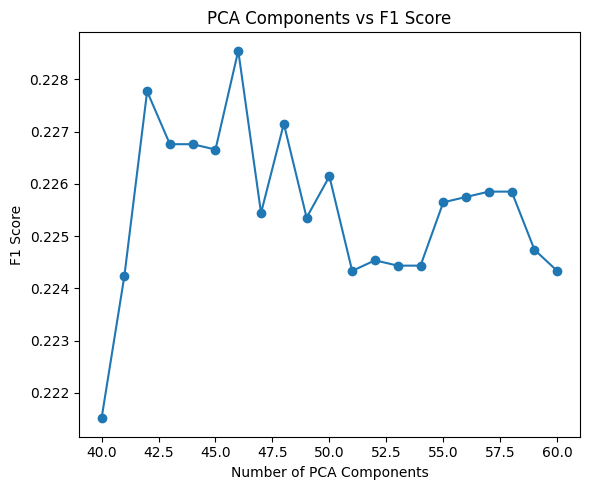

In [32]:
components = list(range(40, 61))

f1_scores = [
    0.22151321786690975,
    0.22423146473779385,
    0.2277676950998185,
    0.22675736961451248,
    0.22675736961451248,
    0.22665457842248413,
    0.22854561878952123,
    0.2254413761883205,
    0.22714932126696832,
    0.22535211267605634,
    0.2261420171867933,
    0.22433288104929897,
    0.22453598913535536,
    0.2244343891402715,
    0.2244343891402715,
    0.22564567285908474,
    0.2257479601087942,
    0.22585034013605443,
    0.22585034013605443,
    0.2247394653375623,
    0.22433288104929897
]

plt.figure(figsize=(6,5))

plt.plot(components, f1_scores, marker='o')

plt.xlabel("Number of PCA Components")
plt.ylabel("F1 Score")
plt.title("PCA Components vs F1 Score")

plt.tight_layout()
plt.show()

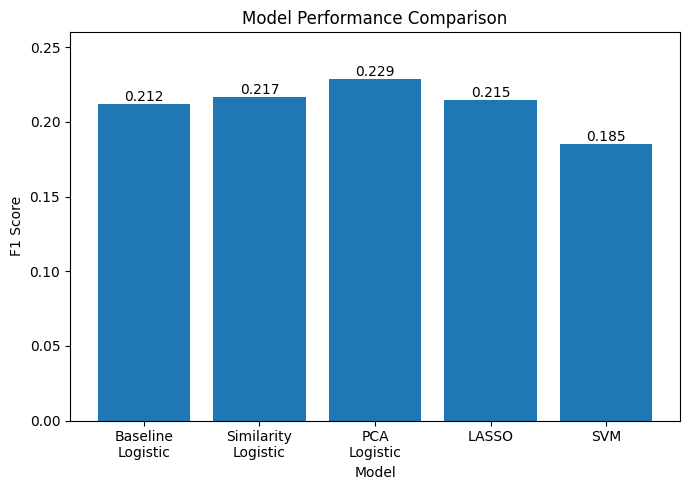

In [34]:
import matplotlib.pyplot as plt

# model names
models = [
    "Baseline\nLogistic",
    "Similarity\nLogistic",
    "PCA\nLogistic",
    "LASSO",
    "SVM"
]

# corresponding F1 scores
f1_scores = [
    0.212,
    0.217,
    0.229,
    0.215,
    0.185   # replace with your final SVM score if different
]

plt.figure(figsize=(7,5))

bars = plt.bar(models, f1_scores)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Model Performance Comparison")

# add value labels above bars
for bar, score in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{score:.3f}",
        ha='center'
    )

plt.ylim(0, 0.26)

plt.tight_layout()
plt.show()

In [36]:

# original metadata feature names
metadata_features = list(X.columns)

# PCA component names
pca_features = [f"PCA_{i+1}" for i in range(emb_train_reduced.shape[1])]

# combine all feature names
all_features = metadata_features + pca_features

# build coefficient dataframe
coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": model_pca.coef_[0]
})

# sort by strongest positive coefficients
coef_df = coef_df.sort_values(
    by="coefficient",
    ascending=False
)

# display top 20
print(coef_df.head(20))

         feature  coefficient
67        PCA_25     1.577243
48         PCA_6     1.450599
83        PCA_41     1.300987
69        PCA_27     1.014652
84        PCA_42     0.859852
71        PCA_29     0.693892
74        PCA_32     0.617730
82        PCA_40     0.515196
60        PCA_18     0.470117
55        PCA_13     0.449396
2    dev_success     0.427326
53        PCA_11     0.349469
86        PCA_44     0.302169
75        PCA_33     0.273963
78        PCA_36     0.244552
45         PCA_3     0.240512
79        PCA_37     0.233118
81        PCA_39     0.205181
22  Free To Play     0.181588
89        PCA_47     0.168515


In [38]:

# number of PCA components
N_COMPONENTS = 46

# fit PCA
pca = PCA(
    n_components=N_COMPONENTS,
    random_state=42
)

# split embeddings
emb_train = embedding_matrix[:split_index]
emb_test = embedding_matrix[split_index:]

# transform embeddings
emb_train_reduced = pca.fit_transform(emb_train)
emb_test_reduced = pca.transform(emb_test)

# =========================
# REBUILD FINAL FEATURE MATRICES
# =========================

X_train_final = np.hstack([
    X_train_scaled,
    emb_train_reduced
])

X_test_final = np.hstack([
    X_test_scaled,
    emb_test_reduced
])

# =========================
# RETRAIN PCA MODEL
# =========================

model_pca = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

model_pca.fit(
    X_train_final,
    y_train
)

# =========================
# EVALUATE
# =========================

y_probs = model_pca.predict_proba(
    X_test_final
)[:, 1]

y_pred = (y_probs > 0.6).astype(int)

print("F1:", f1_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

print(confusion_matrix(
    y_test,
    y_pred
))

F1: 0.22854561878952123
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     33069
           1       0.24      0.22      0.23      1142

    accuracy                           0.95     34211
   macro avg       0.60      0.60      0.60     34211
weighted avg       0.95      0.95      0.95     34211

[[32250   819]
 [  889   253]]


In [50]:


new_dev_mask = X_test['dev_had_success'] == 0

X_test_newdev = X_test_final[new_dev_mask]

y_test_newdev = y_test[new_dev_mask]

y_probs_newdev = model_pca.predict_proba(
    X_test_newdev
)[:, 1]

y_pred_newdev = (y_probs_newdev > 0.35).astype(int)

print("F1:", f1_score(y_test_newdev, y_pred_newdev))

print(classification_report(
    y_test_newdev,
    y_pred_newdev
))

print(confusion_matrix(
    y_test_newdev,
    y_pred_newdev
))

F1: 0.11924381968007755
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     30163
           1       0.07      0.32      0.12       765

    accuracy                           0.88     30928
   macro avg       0.53      0.61      0.53     30928
weighted avg       0.96      0.88      0.92     30928

[[27048  3115]
 [  519   246]]


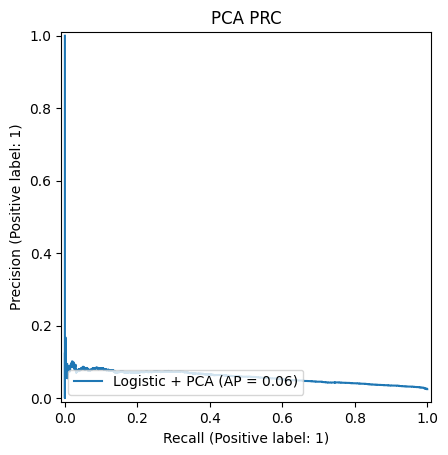

In [44]:
PrecisionRecallDisplay.from_estimator(
    model_pca,
    X_test_newdev,
    y_test_newdev,
    name="Logistic + PCA"
)

plt.title("PCA PRC")
plt.show()